<a href="https://colab.research.google.com/github/MuhammaadArsalanZahid/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FlyRank ML Capstone — Research Paper

## From Search Signals to Human-Reviewed Content Actions

**Track:** Machine Learning  
**Assignment:** ML-11 — Ship the Paper

This notebook assembles the final research artifact from ML-07 through ML-10. It uses actual generated artifacts where available and does not invent model metrics.


## 1. Question

### Research question

Can transparent search-performance signals support prioritization of content pages for human review, and can a machine-learning model provide useful decision-support beyond a simple baseline?

### Scope

The output is a ranked review queue containing an action score, a reason code, and an action label. It is not an autonomous content-editing system.

Claims are deliberately framed as **observed**, **measured**, **directional**, and **decision-support** rather than causal guarantees.


## 2. Abstract

This project investigates whether current search-performance signals can support transparent prioritization of content pages for human review. The workflow starts with a rule-based baseline using CTR, average position, and impressions, followed by a machine-learning model evaluated on the same task and evaluation design. Validation is strengthened through an honest grouped or time-aware design and a leakage audit so that future information is not used to create an unrealistically strong result. The final output is a ranked action queue with reason codes and human-review guidance rather than an autonomous content-editing system. Results are interpreted as directional decision-support evidence and not as a causal guarantee that changing a page will improve SEO performance.


## 3. Data

The project uses the `content_refresh_anonymized.csv` dataset supplied for the FlyRank ML Internship workflow.

Core signals used by the baseline/action workflow include:
- CTR
- average position
- impressions over the available 90-day window

The public artifact must not expose client names, private URLs, private queries, credentials, or other identifying information.

Future outcomes, post-action results, and decision/label columns must not be used as current decision inputs.


In [1]:

from pathlib import Path
import json
import numpy as np
import pandas as pd

ROOT = Path.cwd()
OUT = ROOT / "work" / "outputs"
FIG = ROOT / "work" / "figures"
SUB = ROOT / "submission"

for p in [OUT, FIG, SUB]:
    p.mkdir(parents=True, exist_ok=True)

candidates = [
    ROOT / "data/raw/content_refresh_anonymized.csv",
    ROOT / "content_refresh_anonymized.csv",
    Path("/content/content_refresh_anonymized.csv"),
]
data_path = next((p for p in candidates if p.exists()), None)

if data_path:
    data = pd.read_csv(data_path)
    print("Loaded:", data_path)
    print("Rows:", len(data), "Columns:", len(data.columns))
else:
    data = None
    print("CSV not found. Upload content_refresh_anonymized.csv if you want fresh figures.")


Loaded: /content/content_refresh_anonymized.csv
Rows: 30000 Columns: 53


## 4. Methodology

### Baseline
The Week-4 baseline uses current CTR, average position, and impressions to create a transparent score, one reason code, and one action label.

### Model
The Week-5 model is the model actually executed in `work/notebooks/w05_model.ipynb`. This paper reuses its saved metrics when available rather than inventing results.

### Validation
The Week-6 audit uses an honest grouped or time-aware design and performs a leakage audit. Client grouping is important when multiple rows from one client could otherwise cross train/test boundaries.

### Action playbook
The Week-7 output translates validated signals into ranked actions. Human review is required before implementation.


In [2]:

# Inventory previous JSON receipts.
receipts = {}
for p in sorted(OUT.glob("*.json")):
    try:
        receipts[p.name] = json.loads(p.read_text(encoding="utf-8"))
    except Exception as e:
        receipts[p.name] = {"read_error": str(e)}

print("JSON receipts:", list(receipts) or "None")
for name, obj in receipts.items():
    print("\n---", name, "---")
    print(json.dumps(obj, indent=2)[:3500])


JSON receipts: None


## 5. Results — model versus baseline

The required comparison is the model versus the Week-4 baseline on the **same split and same metric**.

The notebook does not fabricate a metric. If the executed ML-08/ML-09 notebooks saved a metrics JSON under `work/outputs/`, it is inventoried below. If not, run those notebooks and commit their metrics receipts before final deployment.


In [3]:

metric_rows = []
for filename, obj in receipts.items():
    if isinstance(obj, dict):
        scalar = {
            str(k): v for k, v in obj.items()
            if isinstance(v, (int, float, str, bool)) or v is None
        }
        if scalar:
            metric_rows.append({"source": filename, **scalar})

metrics_df = pd.DataFrame(metric_rows)
if len(metrics_df):
    display(metrics_df)
else:
    print("No scalar metrics receipt found in work/outputs/.")


No scalar metrics receipt found in work/outputs/.


### Interpretation rule

Use the actual recorded result to answer:
1. Did the model beat the baseline?
2. By what measured amount?
3. Was the comparison made on the same split and metric?
4. What errors or disagreements were observed?
5. Is the evidence strong enough for decision-support only, or does it justify a stronger conclusion?

If the simpler baseline performs as well as or better than the model, the baseline should remain the preferred reference. Complexity alone is not success.


## 6. Signal visualization

The following figure is descriptive only. It shows an observed relationship between CTR and average position when those columns are available.


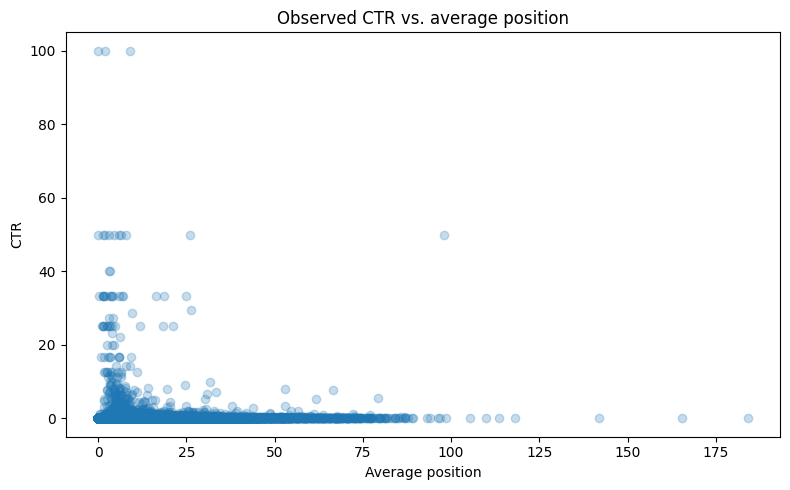

Saved: /content/work/figures/ctr_vs_position.png


In [4]:

import matplotlib.pyplot as plt

if data is not None:
    def find_col(names):
        for name in names:
            if name in data.columns:
                return name
        return None

    ctr_col = find_col(["ctr", "CTR", "avg_ctr", "average_ctr"])
    pos_col = find_col(["avg_position", "position", "average_position"])

    if ctr_col and pos_col:
        plot_df = data[[ctr_col, pos_col]].copy()
        plot_df[ctr_col] = pd.to_numeric(plot_df[ctr_col], errors="coerce")
        plot_df[pos_col] = pd.to_numeric(plot_df[pos_col], errors="coerce")
        plot_df = plot_df.dropna()
        if len(plot_df) > 10000:
            plot_df = plot_df.sample(10000, random_state=42)

        plt.figure(figsize=(8,5))
        plt.scatter(plot_df[pos_col], plot_df[ctr_col], alpha=0.25)
        plt.xlabel("Average position")
        plt.ylabel("CTR")
        plt.title("Observed CTR vs. average position")
        plt.tight_layout()
        fig_path = FIG / "ctr_vs_position.png"
        plt.savefig(fig_path, dpi=160, bbox_inches="tight")
        plt.show()
        print("Saved:", fig_path)
    else:
        print("CTR/position columns not detected.")
else:
    print("Upload the CSV to generate the figure.")


## 7. Limitations & honest framing

- The signals are observational.
- Search intent, SERP composition, seasonality, site changes, and measurement quality can affect the observed values.
- A model/rule score identifies review opportunities; it does not prove that an edit will improve outcomes.
- Validation quality depends on the exact split and available labels/outcomes.
- An anonymized dataset does not support client-specific public conclusions.
- Recommendations require human review.

Prefer phrases such as **we observed**, **the analysis measured**, **the queue prioritizes**, and **directional decision-support**.

Avoid claims such as **this causes**, **this guarantees**, or **the model will improve rankings**.


## 8. Ranked recommendations

The ML-10 action playbook should be used as the source for the final ranked queue.

Recommended workflow:
1. High-visibility CTR opportunity → review title/snippet alignment, search intent, and page relevance.
2. Mid-position opportunity → review content depth, intent match, internal linking, and snippet opportunity.
3. Low-confidence opportunity → monitor and collect more evidence before editing.

### No-go cases

Do not automatically publish, delete, rewrite, redirect, canonicalize, or deindex content based only on the score.


In [5]:

queue_candidates = [
    OUT / "baseline_action_playbook.csv",
    OUT / "baseline_action_score.csv"
]
queue_path = next((p for p in queue_candidates if p.exists()), None)

if queue_path:
    action_queue = pd.read_csv(queue_path)
    print("Loaded:", queue_path)
    display(action_queue.head(10))
else:
    action_queue = None
    print("No action queue found. Run ML-07/ML-10 first.")


No action queue found. Run ML-07/ML-10 first.


## 9. Reproducibility

Key notebooks:

- `work/notebooks/w04_baseline_score.ipynb`
- `work/notebooks/w05_model.ipynb`
- `work/notebooks/w06_validation_audit.ipynb`
- `work/notebooks/w07_action_playbook.ipynb`
- `work/notebooks/capstone.ipynb`

Run them in order, then run this notebook. Generated queue files are regenerated rather than manually edited.

The public repository should not contain private data, credentials, client identifiers, private URLs, or other sensitive information.


## 10. Acknowledgments & data credit

Built on the FlyRank ML Internship dataset.

FlyRank: https://flyrank.ai

This artifact uses anonymized/public-safe internship data and does not disclose client names, private URLs, private search queries, credentials, or other sensitive information.


In [6]:

paper_url_file = SUB / "paper_url.txt"

print("Required notebook paths:")
for rel in [
    "work/notebooks/w04_baseline_score.ipynb",
    "work/notebooks/w05_model.ipynb",
    "work/notebooks/w06_validation_audit.ipynb",
    "work/notebooks/w07_action_playbook.ipynb",
]:
    p = ROOT / rel
    print(("FOUND " if p.exists() else "MISSING "), rel)

if paper_url_file.exists():
    url = paper_url_file.read_text(encoding="utf-8").strip()
    print("\npaper_url.txt:", url or "(empty)")
else:
    print("\npaper_url.txt not created yet.")


Required notebook paths:
MISSING  work/notebooks/w04_baseline_score.ipynb
MISSING  work/notebooks/w05_model.ipynb
MISSING  work/notebooks/w06_validation_audit.ipynb
MISSING  work/notebooks/w07_action_playbook.ipynb

paper_url.txt not created yet.


## 12. Conclusion

This project presents a reproducible workflow from search-performance signals to a human-reviewed content action queue. The baseline provides a transparent reference point; the Week-5 model is compared with that reference; the Week-6 audit checks validation and leakage; and the Week-7 playbook turns validated signals into practical recommendations.

The final artifact is best described as a **transparent, public-safe decision-support workflow**, not an autonomous SEO optimizer or a causal guarantee of future performance.
